# Домашнее задание 8: Face Recognition и Image Retrieval

В этом домашнем задании поработаем с датасетом Friends — https://www.kaggle.com/datasets/amiralikalbasi/images-of-friends-character-for-face-recognition/data — и с помощью библиотеки InsightFace реализуем простую систему распознавания лиц. План работы:
1. Посчитаем датасет и представим его в удобном формате.
2. Реализуем функцию для детектирования лиц и извлечения эмбеддингов.
3. Визуализируем результаты.
4. Реализуем функцию для вычисления схожести лиц.
5. Реализуем систему поиска человека на групповом фото.
6. Реализуем функцию для подсчёта метрики mAP.

In [ ]:
import os
from collections import defaultdict

import insightface
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

### Задание 1: Работа с датасетом

В качестве первого задания по традиции реализуем функцию для работы с датасетом. Напишите функцию, которая вернёт DataFrame, каждый ряд которого содержит имя человека, путь к фотографии, bounding box и эмбеддинг. Последние два столбца пока оставим пустыми и заполним в следующих заданиях. Пока загрузите только train-часть датасета.

In [ ]:
def create_face_dataset(root_dir: str = 'dataset') -> pd.DataFrame:
    pass


dir_path = None # путь к данным
dataset = create_face_dataset(dir_path)
dataset.head()

### Задание 2: Нахождение лиц и извлечение эмбеддингов

В этом задании реализуем функцию, которая будет детектировать лица на изображении и извлекать их эмбеддинги, для этого воспользуемся библиотекой InsightFace. Функция должна принимать на вход путь к изображению и модель InsightFace, а возвращать словарь с эмбеддингами и bounding box. Обратите внимание, что метод get модели ожидает BGR-изображение.

In [ ]:
model = insightface.app.FaceAnalysis(providers=['CPUExecutionProvider', 'CUDAExecutionProvider'])
model.prepare(ctx_id=0)

Applied providers: ['CPUExecutionProvider', 'CUDAExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0'}}
find model: C:\Users\asang/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider', 'CUDAExecutionProvider'], with options: {'CPUE

In [ ]:
def extract_face_embeddings(model: insightface.app.FaceAnalysis, image_path: str) -> dict[str, list[np.ndarray]]:
    pass

Отлично, теперь мы можем извлечь эмбеддинги и bounding box для каждого изображения в датасете.

In [ ]:
annotations = dataset.apply(lambda row: extract_face_embeddings(model, row['path']), axis=1)

dataset['embeddings'] = annotations.apply(lambda x: x['embeddings'])
dataset['bboxes'] = annotations.apply(lambda x: x['bboxes'])

dataset.head()

Дропнем строки с пустыми эмбеддингами и bounding box, т. к. некоторые изображения сняты очень близко и лицо не детектируется.

In [ ]:
dataset = dataset[(dataset['embeddings'].str.len() > 0) & (dataset['bboxes'].str.len() > 0)]
dataset.head()

In [ ]:
dataset.to_parquet("train_meta.parquet", index=False)

Загрузите метаданные датасета в LMS.

### Задание 3: Визуализация лиц


Подготовимся к последующим заданиям, напишем функцию для визуализации лиц. Она должна принимать на вход путь к изображению, bounding box и лейбл, а возвращать изображение с нарисованными bounding box. Также функция должна выводить изображение с помощью matplotlib.

In [ ]:
def visualize_faces(image_path: str, bboxes: list[np.ndarray], labels: list[str]) -> np.ndarray:
    pass

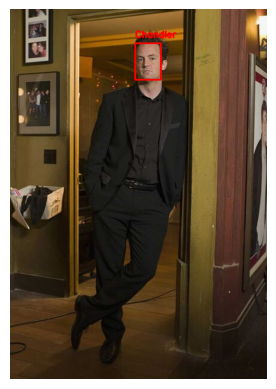

In [ ]:
sample = visualize_faces(dataset.iloc[0]['path'], dataset.iloc[0]['bboxes'], [dataset.iloc[0]['person_name']])

### Задание 4: Подсчёт схожести лиц

Теперь напишем функцию, которая будет считать схожесть двух лиц по их эмбеддингам. В качестве метрик схожести возьмём L2 расстояние и косинусное расстояние, функция должна принимать на вход два эмбеддинга и параметр metric, который может принимать значения 'l2' или 'cosine'.

In [ ]:
def calculate_similarity(embedding1: np.ndarray, embedding2: np.ndarray, metric: str = 'l2') -> float:
    pass

In [ ]:
sample_ch = dataset[dataset['person_name'] == 'Chandler'].iloc[0]
sample_r = dataset[dataset['person_name'] == 'Ross'].iloc[0]
sample_m = dataset[dataset['person_name'] == 'Monica'].iloc[0]

In [ ]:
print("Similarity between Chandler and Monica:", calculate_similarity(sample_ch['embeddings'][0], sample_m['embeddings'][0], metric='cosine'))
print("Similarity between Chandler and Ross:", calculate_similarity(sample_ch['embeddings'][0], sample_r['embeddings'][0], metric='cosine'))

Similarity between Chandler and Monica: 0.0453193
Similarity between Chandler and Ross: 0.1465379


### Задание 5: Поиск на групповом фото

Напишите функцию, которая будет принимать на вход наш датасет в виде датафрейма, а также путь к групповому фото. Функция должна возвращать словарь, где ключами являются имена людей на фотографии, а значениями — пара (bounding box, similarity). Гарантируется, что каждый человек встретится только единожды в рамках одной фотографии.

In [ ]:
def process_group_photo(model: insightface.app.FaceAnalysis, dataset: pd.DataFrame, image_path: str) -> dict[str, list[np.ndarray]]:
    pass

In [ ]:
test_dir = os.path.join(dir_path, "Test")
test_dataset = []
for sample in os.listdir(test_dir):
    test_dataset.append({'photo_path': os.path.join(test_dir, sample),
                         'characters': [],
                         'bboxes': [],
                         'similarity': []})
test_dataset = pd.DataFrame(test_dataset)
test_dataset.head()

In [ ]:
... # Запроцессьте все фото в тестовой части датасета

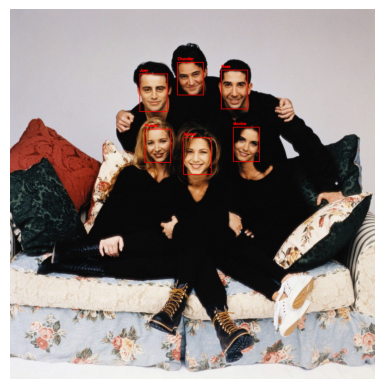

In [ ]:
sample = test_dataset.iloc[4]
group_vis = visualize_faces(sample['photo_path'], [bbox for bbox in sample['bboxes']], sample['characters'])

In [ ]:
test_dataset.to_parquet("test_meta.parquet", index=False)

Загрузите parquet в LMS.

### Задание 6: Подсчёт метрики mAP

Напишем функцию для подсчёта метрики mAP на групповом фото, функция должна принимать на вход словарь с предсказаниями и словарь с gt.

In [ ]:
def calculate_map(predictions: dict[str, tuple[np.ndarray, float]], targets: dict[str, np.ndarray]) -> float:
    pass

In [ ]:
sample = test_dataset.iloc[4]

true_bboxes = (np.array([541, 270, 657, 427]),
    np.array([881, 254, 991, 416]),
    np.array([723, 536, 839, 689]),
    np.array([561, 500, 669, 639]),
    np.array([698, 222, 806, 358]),
    np.array([ 931,  492, 1040,  635]))

true_characters = ['Joey', 'Ross', 'Rachel', 'Phoebe', 'Chandler', 'Monica']

calculate_map({name: (bbox, 1) for name, bbox in zip(sample['characters'], sample['bboxes'])}, {name: bbox for name, bbox in zip(true_characters, true_bboxes)})

Загрузите в LMS код функции, а также `test_meta.parquet` из прошлого задания.

### Заключение

Отлично! В этом домашнем задании мы сделали простую систему распознавания лиц и с помощью неё обработали групповые фото — обнаружили на них лица из «базы данных», которую построили на основе одиночных фото.